In [1]:
import tsfel
import cfg_map
import scipy.io
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import scipy.sparse as sp
from scipy.sparse.linalg import eigsh

from sklearn.metrics import accuracy_score
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler, LabelEncoder

from scipy.sparse.csgraph import connected_components

# Setting metadata and params

In [2]:
df_meta = pd.read_csv(cfg_map.METADATA_PATH)
features_to_keep = ['Mean', 'Standard deviation', 'Root mean square', 'Variance', 'Median']

# Feature set extraction

In [3]:

all_feature_dfs = []

# 1. Configure TSFEL to only extract the features we care about
cfg = tsfel.get_features_by_domain('statistical')
for feature in cfg['statistical']:
    cfg['statistical'][feature]['use'] = 'yes' if feature in features_to_keep else 'no'


# 2. Process files and attach labels
for _, row in df_meta.iterrows():
    # Load signal
    info = cfg_map.METADATA_MAPPING[row['id']]
    mat = scipy.io.loadmat(info['path'], variable_names=[info['data_key']])
    signal = mat[info['data_key']].flatten()

    # Extract features for THIS file specifically
    # TSFEL handles the segmentation (1024 points) automatically
    temp_df = tsfel.time_series_features_extractor(
        cfg,
        signal,
        window_size=1024,
        fs=12000,
        verbose=False
    )

    # Add the label (fault_type) to every segment extracted from this file
    temp_df['label'] = row['fault_type']

    # Optional: Add other meta if needed (e.g., load or fault_size)
    # temp_df['load'] = row['load']
    all_feature_dfs.append(temp_df)

# 3. Combine everything into one final labeled dataset
final_df = pd.concat(all_feature_dfs, ignore_index=True)

# 4. Save to Current Working Directory
file_name = ("labeled_features.csv")
final_df.to_csv(file_name, index=False)

print(f"Extraction complete. Labeled dataset saved: {final_df.shape}")
print(final_df['label'].value_counts())
print(f"Final dataset shape: {final_df.shape}")

Process SpawnPoolWorker-159:
Process SpawnPoolWorker-165:
Process SpawnPoolWorker-164:
Process SpawnPoolWorker-163:
Process SpawnPoolWorker-157:
Process SpawnPoolWorker-167:
Process SpawnPoolWorker-166:
Process SpawnPoolWorker-161:
Process SpawnPoolWorker-160:
Process SpawnPoolWorker-158:
Process SpawnPoolWorker-162:
Process SpawnPoolWorker-168:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib64/python3.14/multiprocessing/process.py", line 320, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/usr/lib64/python3.14/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib64/python3.14/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/usr/lib64/python3.14/multiprocessing/queues.py", line 385, in get
    res = self._reader.recv_bytes()
  File "/usr/lib64/python3.14/multiprocessing/connection.py", line 222, in recv_bytes
    buf = s

KeyboardInterrupt: 

# Seperating the Labels from the Feature set

In [ ]:
def load_features(file_path, meta_cols=['file_id', 'fault_size', 'load'], label_col='label'):
    if meta_cols is None:
        meta_cols = []

    df = pd.read_csv(file_path)
    X = df.drop(columns=meta_cols + [label_col]).values

    # 1. Initialize LabelEncoder to handle the string labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(df[label_col].values)

    # Store the classes for the evaluation report
    target_names = le.classes_

    return X, y_encoded, target_names

def preprocess_features(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled

In [ ]:
def laplacian_eigenmaps(X, n_components=2, k=10, normalized=True):
    """
    Compute Laplacian Eigenmaps embedding.

    Parameters:
    - X: (n_samples, n_features)
    - n_components: embedding dimension
    - k: number of neighbors
    - normalized: use normalized Laplacian

    Returns:
    - embedding: (n_samples, n_components)
    """

    # -----------------------------
    # 1. Normalize features
    # -----------------------------
    X = StandardScaler().fit_transform(X)

    # -----------------------------
    # 2. KNN graph (distance)
    # -----------------------------
    A = kneighbors_graph(X, n_neighbors=k, mode='distance', include_self=False)

    # -----------------------------
    # 3. Symmetrize (safer than mutual KNN)
    # -----------------------------
    A = (0.5 * (A + A.T)).tocsr()

    # -----------------------------
    # 4. Local scaling (self-tuning kernel)
    # -----------------------------
    sigma = A.max(axis=1).toarray().ravel()
    sigma[sigma == 0] = 1e-10  # avoid division by zero

    rows, cols = A.nonzero()
    dists = A.data

    W_data = np.exp(-(dists ** 2) / (sigma[rows] * sigma[cols]))
    W = sp.csr_matrix((W_data, (rows, cols)), shape=A.shape)

    # -----------------------------
    # 5. Degree matrix
    # -----------------------------
    degrees = np.array(W.sum(axis=1)).flatten()
    degrees[degrees == 0] = 1e-10  # stability
    D = sp.diags(degrees)

    # -----------------------------
    # 6. Check connectivity
    # -----------------------------
    n_comp, _ = connected_components(W)
    if n_comp > 1:
        print(f"!!Graph not fully connected ({n_comp} components). Consider increasing k.")

    # -----------------------------
    # 7. Laplacian
    # -----------------------------
    if normalized:
        D_inv_sqrt = sp.diags(1.0 / np.sqrt(degrees))
        L = D_inv_sqrt @ (D - W) @ D_inv_sqrt
        eig_kwargs = {"which": "SM"}
    else:
        L = D - W
        eig_kwargs = {"M": D, "which": "LM", "sigma": 0}

    # -----------------------------
    # 8. Eigen decomposition
    # -----------------------------
    eigvals, eigvecs = eigsh(
        L,
        k=n_components + 5,  # extra to safely skip zero eigenvalues
        **eig_kwargs
    )

    # -----------------------------
    # 9. Remove zero eigenvalues
    # -----------------------------
    tol = 1e-8
    valid = eigvals > tol

    embedding = eigvecs[:, valid][:, :n_components]

    return embedding

In [ ]:
import numpy as np
from scipy.linalg import pinv


def compute_spectral_gap(eigenvalues, tol=1e-10):
    """
    Compute the minimum non-zero spectral gap between consecutive eigenvalues.

    The spectral gap is defined as:
        gap_i = λ_{i+1} - λ_i

    This quantity is critical in first-order perturbation theory, as it governs
    the stability of eigenvalues and eigenvectors under small perturbations.
    A larger gap implies greater robustness.

    Parameters
    ----------
    eigenvalues : ndarray of shape (k,)
        Sorted or unsorted eigenvalues of the Laplacian matrix.
    tol : float, optional (default=1e-10)
        Numerical tolerance to filter out near-zero gaps due to floating-point precision.

    Returns
    -------
    min_gap : float
        The smallest non-zero spectral gap.

    Raises
    ------
    ValueError
        If all eigenvalues are effectively identical (no valid gap).

    Notes
    -----
    Used in Theorem 1 (Spectral Gap) to bound perturbations:
        |λ_i' - λ_i| < gap / 2
    """
    eigenvalues = np.sort(eigenvalues)
    gaps = np.diff(eigenvalues)

    valid_gaps = gaps[gaps > tol]
    if len(valid_gaps) == 0:
        raise ValueError("Eigenvalues are degenerate; no valid spectral gap.")

    return np.min(valid_gaps)


def compute_reduced_resolvent(L, eigenvalues, idx):
    """
    Compute the reduced resolvent (Moore–Penrose pseudoinverse) of a shifted Laplacian.

    The reduced resolvent is defined as:
        S = (L - λ_i I)^+

    where λ_i is a selected eigenvalue and (+) denotes the pseudoinverse.

    This operator captures the sensitivity ("stiffness") of eigenvectors to perturbations
    and plays a central role in eigenvector perturbation analysis.

    Parameters
    ----------
    L : ndarray of shape (n, n)
        Graph Laplacian matrix.
    eigenvalues : ndarray of shape (k,)
        Eigenvalues corresponding to L.
    idx : int
        Index of the eigenvalue λ_i (e.g., 1 for the Fiedler eigenvalue).

    Returns
    -------
    S : ndarray of shape (n, n)
        Reduced resolvent matrix.

    Notes
    -----
    Used in Theorem 2 (Reduced Resolvent) to characterize eigenvector perturbations.
    """
    n = L.shape[0]
    L_shifted = L - eigenvalues[idx] * np.eye(n)
    return pinv(L_shifted)


def generate_laplacian_noise(n, scale, random_state=None):
    """
    Generate a symmetric Laplacian noise matrix with zero row-sum constraint.

    The generated noise matrix E satisfies:
        - Symmetry: E = E^T
        - Zero row-sum: sum_j E[i, j] = 0 (Laplacian structure)

    This ensures that adding E to a Laplacian preserves its structural properties.

    Parameters
    ----------
    n : int
        Number of nodes (matrix dimension).
    scale : float
        Scale parameter of the Laplace distribution.
    random_state : int or None, optional
        Seed for reproducibility.

    Returns
    -------
    E : ndarray of shape (n, n)
        Symmetric noise matrix with Laplacian structure.

    Notes
    -----
    The Laplace mechanism ensures differential privacy, while the structural
    constraints maintain spectral interpretability.
    """
    rng = np.random.default_rng(random_state)

    noise_upper = rng.laplace(loc=0.0, scale=scale, size=(n, n))
    noise_upper = np.triu(noise_upper, k=1)

    E = noise_upper + noise_upper.T
    np.fill_diagonal(E, -E.sum(axis=1))

    return E


def calculate_sensitivity_and_noise(
    L,
    eigenvectors,
    eigenvalues,
    epsilon=1.0,
    fiedler_index=1,
    random_state=None
):
    """
    Compute noise matrix and reduced resolvent under spectral perturbation constraints.

    This function integrates:
    - Theorem 1: Spectral gap-based stability control
    - Theorem 2: Reduced resolvent for eigenvector sensitivity
    - Differential privacy via Laplace noise

    The noise scale is calibrated such that the expected eigenvalue perturbation
    remains bounded relative to the spectral gap.

    Parameters
    ----------
    L : ndarray of shape (n, n)
        Graph Laplacian matrix.
    eigenvectors : ndarray of shape (n, k)
        Eigenvectors corresponding to selected components.
    eigenvalues : ndarray of shape (k,)
        Eigenvalues corresponding to the eigenvectors.
    epsilon : float, optional (default=1.0)
        Privacy parameter controlling noise magnitude.
    fiedler_index : int, optional (default=1)
        Index of the eigenvalue used for reduced resolvent computation.
    random_state : int or None, optional
        Random seed for reproducibility.

    Returns
    -------
    E : ndarray of shape (n, n)
        Noise matrix to be added to the Laplacian.
    S : ndarray of shape (n, n)
        Reduced resolvent matrix.
    scale : float
        Noise scale used in Laplace distribution.

    Notes
    -----
    Noise scale is derived to satisfy:
        perturbation magnitude < (spectral gap) / 2

    ensuring stability of eigenspace under first-order perturbation theory.
    """
    n = L.shape[0]
    k = eigenvectors.shape[1]

    min_gap = compute_spectral_gap(eigenvalues)
    S = compute_reduced_resolvent(L, eigenvalues, fiedler_index)

    sensitivity = 2.0 / n
    scale = (min_gap / (2.0 * k)) * (epsilon / sensitivity)

    E = generate_laplacian_noise(n, scale, random_state)

    return E, S, scale


def generate_eigenprojectors(eigenvectors):
    """
    Generate eigenprojector matrices from a set of eigenvectors.

    Each projector is defined as:
        P_i = v_i v_i^T

    where v_i is the i-th eigenvector.

    These projectors represent orthogonal subspaces and are invariant to
    sign flips of eigenvectors, making them more stable for downstream tasks.

    Parameters
    ----------
    eigenvectors : ndarray of shape (n, k)
        Matrix whose columns are eigenvectors.

    Returns
    -------
    projectors : ndarray of shape (k, n, n)
        Stack of projection matrices.

    Notes
    -----
    Corresponds to Theorem 3 (Eigenprojector Stability).

    Projectors are preferred over raw eigenvectors in classification tasks
    due to their robustness under perturbations.
    """
    Q, _ = np.linalg.qr(eigenvectors)
    projectors = np.einsum('ij,ik->jik', Q, Q)
    return projectors

In [ ]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, accuracy_score


def run_classification(embedding, y, target_names=None, models=None):
    if target_names is not None:
        target_names = list(target_names)

    if models is None:
        models = {
            "Logistic Regression": LogisticRegression(max_iter=500, solver="saga", random_state=42),
            "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
            "SVM":                 SVC(kernel="rbf", probability=True, random_state=42),
            "KNN":                 KNeighborsClassifier(n_neighbors=5),
            "Decision Tree":       DecisionTreeClassifier(random_state=42),
        }

    results = {}

    for name, clf in models.items():
        y_pred = cross_val_predict(clf, embedding, y, cv=10)
        report = classification_report(
            y, y_pred,
            target_names=target_names,
            output_dict=True,       # <-- structured dict instead of print
            zero_division=0
        )
        results[name] = {
            "classes": [
                {
                    "name":      cls,
                    "precision": round(report[cls]["precision"], 4),
                    "recall":    round(report[cls]["recall"], 4),
                    "f1":        round(report[cls]["f1-score"], 4),
                    "support":   int(report[cls]["support"]),
                }
                for cls in (target_names or sorted(set(str(c) for c in y)))
            ],
            "accuracy":        round(report["accuracy"], 4),
            "macro_f1":        round(report["macro avg"]["f1-score"], 4),
            "macro_precision": round(report["macro avg"]["precision"], 4),
            "macro_recall":    round(report["macro avg"]["recall"], 4),
        }

    return results

In [ ]:
import pandas as pd
from IPython.display import display

def display_classification_results(results, display_summary=True):
    """
    Displays classification results in clean, research-level tables:
    1. Per-class metrics for each model
    2. Macro-averaged summary across all models, ranked by Macro F1
    """

    # ── 1. Per-class table ───────────────────────────────────────────────
    rows = []
    for model, data in results.items():
        for cls in data["classes"]:
            rows.append({
                "Model": model,
                "Class": cls["name"],
                "Precision": cls["precision"],
                "Recall": cls["recall"],
                "F1": cls["f1"],
                "Support": cls["support"],
            })
    df_class = pd.DataFrame(rows)

    # ── 2. Macro summary table ───────────────────────────────────────────
    summary_rows = []
    for model, data in results.items():
        summary_rows.append({
            "Model": model,
            "Accuracy": data["accuracy"],
            "Macro Precision": data["macro_precision"],
            "Macro Recall": data["macro_recall"],
            "Macro F1": data["macro_f1"],
        })
    df_summary = pd.DataFrame(summary_rows).sort_values("Macro F1", ascending=False)

    # ── Styling function ────────────────────────────────────────────────
    def style_table(df, metric_cols):
        return (
            df.style
            .format({c: "{:.3f}" for c in metric_cols})
            .highlight_max(subset=metric_cols, props="font-weight: bold;")
            .set_properties(**{"text-align": "center", "font-family": "Arial", "font-size": "12px"})
            .set_table_styles([
                {"selector": "thead th", "props": [("font-weight", "bold"), ("text-align", "center")]},
                {"selector": "tbody td", "props": [("padding", "4px 8px")]},
            ])
        )

    # ── Display ─────────────────────────────────────────────────────────

    if not display_summary:
        display(df_class.style.format({
            "Precision": "{:.3f}", "Recall": "{:.3f}", "F1": "{:.3f}"
        }).set_properties(**{"text-align": "center", "font-family": "Arial"}).set_caption("Per-class metrics"))

    display(style_table(df_summary, ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]).set_caption("Macro summary — ranked by Macro F1"))

In [ ]:
def run_cv_inference_attack(X, y, sensitive_class):
    """
    10-Fold CV Inference Attack with nicely printed results.
    """
    # 1. Create the adversary's binary target (Target vs. All Others)
    y_adversary = (y == sensitive_class).astype(int)

    # 2. Define the adversaries
    adversaries = {
        "Logistic Regression (LR)": LogisticRegression(max_iter=2000, class_weight='balanced'),
        "Random Forest (RF)": RandomForestClassifier(n_estimators=100, class_weight='balanced')
    }

    # 3. Calculate Random Baseline
    baseline = max(y_adversary.mean(), 1.0 - y_adversary.mean())

    results = {}
    for name, clf in adversaries.items():
        y_pred = cross_val_predict(clf, X, y_adversary, cv=10)
        acc = accuracy_score(y_adversary, y_pred)

        results[name] = {
            "Adversary Accuracy": round(acc, 4),
            "Random Baseline": round(baseline, 4),
            "Privacy Gain": round(baseline - acc, 4)
        }

    # Convert results to DataFrame for nicer display
    results_df = pd.DataFrame(results).T
    print("\n=== Inference Attack Results ===")
    print(results_df)

    # return results_df

In [ ]:
x, y, target_names = load_features(
    file_path="features_raw_0_overlap.csv",
    meta_cols=['file_id', 'fault_size', 'load'],
    label_col='label'
)
X_scaled = preprocess_features(x)

# Checking Performance and privacy on Base Data

In [ ]:
print("Evaluating raw feature performance with multiple classifiers...")
results = run_classification(X_scaled, y, target_names=target_names)
display_classification_results(results)
sensitive_class_name = "B"
sensitive_label = np.where(target_names == sensitive_class_name)[0][0]
run_cv_inference_attack(X_scaled, y, sensitive_class=sensitive_label)

Evaluating raw feature performance with multiple classifiers...


/home/zoso/Codes/privacy-pipeline/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/zoso/Codes/privacy-pipeline/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/zoso/Codes/privacy-pipeline/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/zoso/Codes/privacy-pipeline/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/zoso/Codes/privacy-pipeline/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did 

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Random Forest,0.994,0.996,0.994,0.995
2,SVM,0.981,0.982,0.981,0.982
4,Decision Tree,0.973,0.974,0.975,0.974
3,KNN,0.962,0.962,0.967,0.964
0,Logistic Regression,0.951,0.960,0.949,0.954



=== Inference Attack Results ===
                          Adversary Accuracy  Random Baseline  Privacy Gain
Logistic Regression (LR)              0.9241            0.784       -0.1402
Random Forest (RF)                    0.9512            0.784       -0.1672


# Checking Performance and Privacy on LE embedding

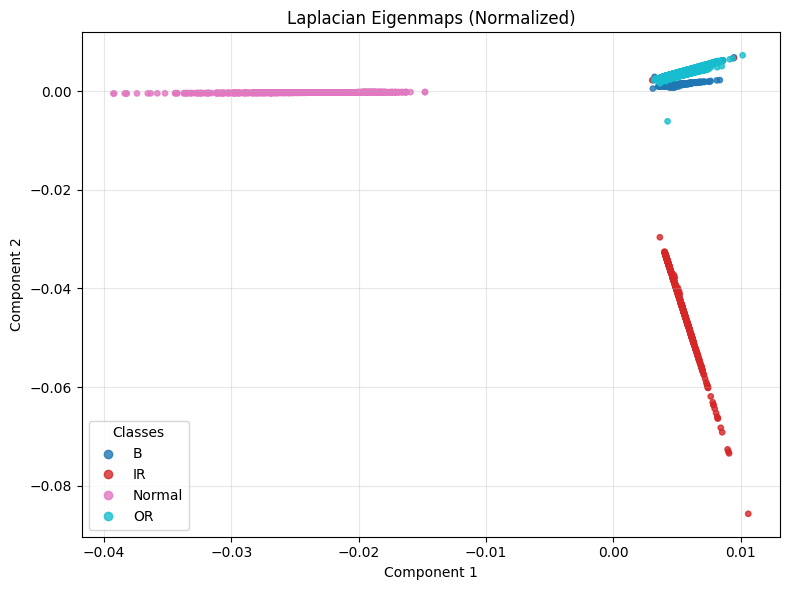

Evaluating Laplacian Eigenmaps embedding performance with multiple classifiers...


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
3,KNN,0.843,0.852,0.854,0.853
1,Random Forest,0.832,0.845,0.841,0.843
4,Decision Tree,0.822,0.833,0.831,0.832
2,SVM,0.665,0.812,0.622,0.624
0,Logistic Regression,0.561,0.866,0.485,0.445



=== Inference Attack Results ===
                          Adversary Accuracy  Random Baseline  Privacy Gain
Logistic Regression (LR)              0.6037            0.784        0.1802
Random Forest (RF)                    0.9037            0.784       -0.1198


In [ ]:
embedding = laplacian_eigenmaps(X_scaled, n_components=3, k=23, normalized=True)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=y,
    cmap='tab10',
    s=15,
    alpha=0.8
)

# Legend
handles, _ = scatter.legend_elements()
plt.legend(handles, target_names, title="Classes")

plt.title("Laplacian Eigenmaps (Normalized)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Evaluating Laplacian Eigenmaps embedding performance with multiple classifiers...")
results = run_classification(embedding, y, target_names=target_names)
display_classification_results(results)
sensitive_class_name = "B"
sensitive_label = np.where(target_names == sensitive_class_name)[0][0]
run_cv_inference_attack(embedding, y, sensitive_class=sensitive_label)